# Qubitized phase estimation with unary-iteration SELECT

**Download Notebook** - {nb-download}`qubitized_phase_estimation.ipynb`

This notebook estimates the ground-state eigenvalue of a four-term, three-qubit Hermitian Hamiltonian. It combines an LCU block encoding with unary-iteration SELECT, controlled qubitization, and canonical QPE, then compares the eigenvalue inferred from sampled phases with the result of exact diagonalization.

In [1]:
from typing import no_type_check

import numpy as np
import zixy.qubit.pauli as zqp
from guppylang import guppy
from guppylang.std.builtins import array, output
from guppylang.std.quantum import (
    collect_measurements,
    discard_array,
    h,
    measure_array,
    qubit,
)

from guppyalgos.primitives.gate_decompositions.cnx.cnx import cnx
from guppyalgos.algorithms.block_encoding.lcu import (
    LCUCntrl,
    LCUData,
    build_cntrl_unary_iteration_select,
)
from guppyalgos.algorithms.phase_estimation import (
    QubitizationRegs,
    qubitized_power_oracle,
    qpe,
)
from guppyalgos.algorithms.block_encoding.qubitization import QubitizationCntrl
from guppyalgos.primitives.subroutines.reflection import ReflectionCntrl
from guppyalgos.algorithms.state_preparation import multiplexor_prep
from guppyalgos.utils import (
    binary_fraction,
    phase_distance_mod_2,
    qarray,
    phase_to_energy_qubitized_qpe,
    transversal,
)

## Construct the Hamiltonian and LCU data

We use the Hermitian Hamiltonian

$$
H = 0.5 Z_0X_1Y_2 + 0.1 X_0Z_1Z_2 + 0.2 Y_0Y_1X_2 + 0.3 X_0X_1Y_2.
$$

`LCUData` extracts the Pauli strings, coefficient amplitudes, normalization $\lambda=\sum_j |\alpha_j|$, and register sizes. Four terms require a two-qubit PREPARE index, which makes `build_cntrl_unary_iteration_select` use unary iteration rather than the one-control SELECT fallback.

For a direct accuracy comparison, we diagonalize $H$ classically and use `multiplexor_prep` to prepare its exact ground-state eigenvector on the (little-endian) target register.

In [2]:
hamiltonian = zqp.RealTermSum.from_str(
    "(0.5, Z0 X1 Y2), (0.1, X0 Z1 Z2), "
    "(0.2, Y0 Y1 X2), (0.3, X0 X1 Y2)"
)
data = LCUData.from_hamiltonian(hamiltonian)
lcu_prepare = multiplexor_prep(data.amplitudes)
cntrl_select = build_cntrl_unary_iteration_select(data)
n_phase_qubits = 5
n_prep_qubits = data.n_prep_qubits
n_state_qubits = data.n_state_qubits

matrix = hamiltonian.to_sparse_matrix(False).toarray()
eigenvalues, eigenvectors = np.linalg.eigh(matrix)
exact_eigenvalue = float(eigenvalues[0])
initial_state = eigenvectors[:, 0]
state_prepare = multiplexor_prep(initial_state)

assert data.n_terms == 4
assert n_prep_qubits == 2
assert np.allclose(
    matrix @ initial_state,
    exact_eigenvalue * initial_state,
)

## Build the powered controlled qubitization oracle

The LCU block applies `PREPARE`, externally controlled unary-iteration `SELECT`, and `PREPARE`$^\dagger$. Combining this block with a controlled reflection about the all-zero PREPARE state gives one controlled qubitization-walk step.

Canonical `qpe` requests runtime powers of that walk. The shared Guppy function `qubitized_power_oracle` repeats the controlled step for the requested power and infers the PREPARE and target register sizes from its arguments. A local three-argument `power_oracle` binds `cntrl_walk` to match the QPE callback signature. The measured program prepares the exact target eigenstate, runs QPE, and emits the little-endian phase-register bitstring.

In [3]:
dagger = object()


@guppy
@no_type_check
def unprepare(prep: array[qubit, n_prep_qubits]) -> None:
    with dagger:
        lcu_prepare(prep)


@guppy
@no_type_check
def cntrl_walk(
    control: qubit,
    prep: array[qubit, n_prep_qubits],
    target: array[qubit, n_state_qubits],
) -> None:
    cntrl_lcu = LCUCntrl(
        lcu_prepare,
        cntrl_select,
        unprepare,
    )
    reflection = ReflectionCntrl[n_prep_qubits](cnx)
    QubitizationCntrl(cntrl_lcu, reflection).compose(
        control, prep, target
    )


@guppy
@no_type_check
def power_oracle(
    control: qubit,
    regs: QubitizationRegs[
        n_prep_qubits,
        array[qubit, n_state_qubits],
    ],
    power: int,
) -> None:
    qubitized_power_oracle(control, regs, power, cntrl_walk)


@guppy
@no_type_check
def main() -> None:
    phase = qarray(n_phase_qubits)
    prep = qarray(n_prep_qubits)
    target = qarray(n_state_qubits)

    state_prepare(target)
    transversal(h, phase)
    regs = QubitizationRegs(prep, target)
    qpe(phase, regs, power_oracle)

    output("qpe_bitstring", collect_measurements(measure_array(phase)))
    discard_array(regs.prep)
    discard_array(regs.target)

## Sample phases and recover the eigenvalue

For a Hamiltonian eigenvalue $E$, the qubitization walk has a conjugate pair of phases satisfying

$$
E = -\lambda\cos(\pi\phi), \qquad \{\phi, 2-\phi\}.
$$

These phases need not lie exactly on the five-qubit QPE grid. Five phase qubits give a grid spacing $\Delta\phi=2/2^5=0.0625$ and a half-bin resolution of $0.03125$. The histograms show both raw counts and normalized probabilities, with dashed lines at the analytical phases. We convert the dominant measured phase back to an eigenvalue and verify that its absolute error from exact diagonalization is less than $0.1$.

In [4]:
n_shots = 200
total_qubits = (
    n_phase_qubits
    + n_prep_qubits
    + n_state_qubits
    + n_prep_qubits
)

# Run finite-shot emulation and extract the measured QPE register counts.
raw_counts = (
    main.emulator(n_qubits=total_qubits)
    .with_seed(5)
    .with_shots(n_shots)
    .run()
    .register_counts()["qpe_bitstring"]
)

# Decode the little-endian QPE bitstrings into phases measured in half-turns.
phase_counts = {
    binary_fraction([bit == "1" for bit in bitstring]): count
    for bitstring, count in raw_counts.items()
}

# Recover the eigenvalue from the dominant phase and compare it with the exact value.
ideal_phase = float(
    np.arccos(-exact_eigenvalue / data.l1_norm) / np.pi
)
ideal_phases = {ideal_phase, 2 - ideal_phase}
dominant_phase = max(phase_counts, key=phase_counts.__getitem__)
estimated_eigenvalue = phase_to_energy_qubitized_qpe(
    dominant_phase, data.l1_norm
)
phase_resolution = 1 / (2**n_phase_qubits)
eigenvalue_error = abs(estimated_eigenvalue - exact_eigenvalue)

assert sum(phase_counts.values()) == n_shots
assert min(
    phase_distance_mod_2(dominant_phase, phase)
    for phase in ideal_phases
) <= phase_resolution
assert eigenvalue_error < 0.1

{
    "dominant_measured_phase": dominant_phase,
    "estimated_eigenvalue": estimated_eigenvalue,
    "exact_eigenvalue": exact_eigenvalue,
    "absolute_error": eigenvalue_error,
}

{'dominant_measured_phase': 0.3125,
 'estimated_eigenvalue': -0.6111272563215626,
 'exact_eigenvalue': -0.6708203932499369,
 'absolute_error': 0.0596931369283743}

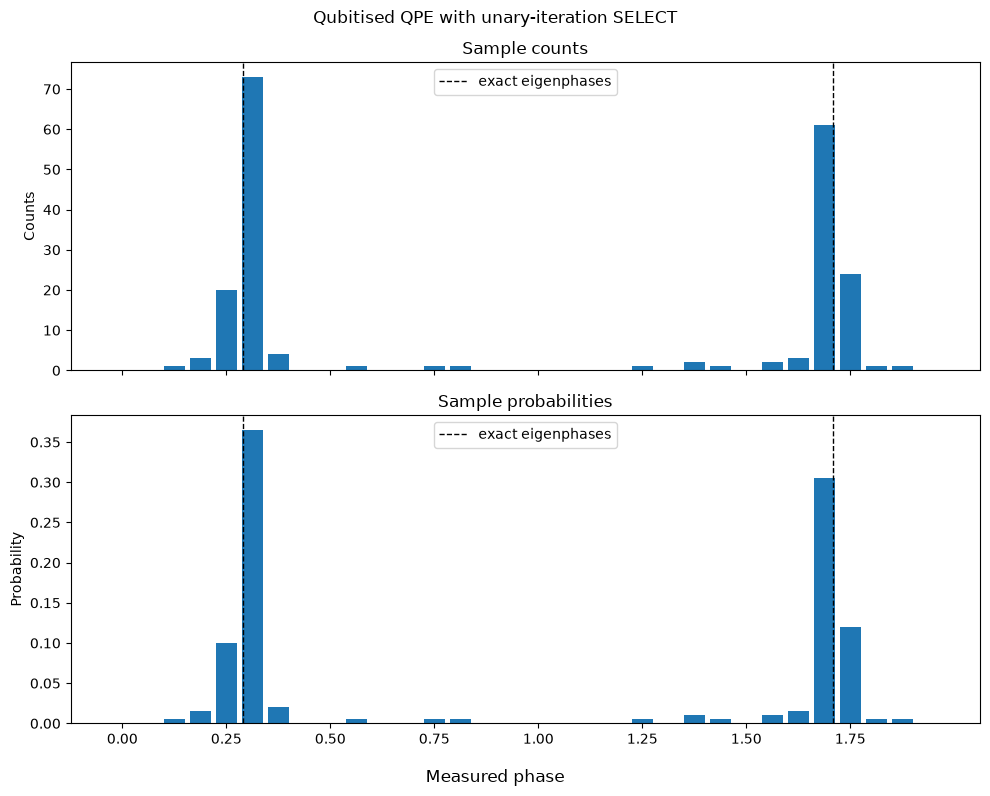

In [5]:
from matplotlib import pyplot as plt

phase_spacing = 2 / (2**n_phase_qubits)
phase_grid = [
    index * phase_spacing
    for index in range(2**n_phase_qubits)
]
counts = [phase_counts.get(phase, 0) for phase in phase_grid]
probabilities = [count / n_shots for count in counts]

fig, (counts_axis, probability_axis) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True
)
bar_width = 0.8 * phase_spacing
counts_axis.bar(phase_grid, counts, width=bar_width)
probability_axis.bar(phase_grid, probabilities, width=bar_width)
for axis in (counts_axis, probability_axis):
    for index, phase in enumerate(sorted(ideal_phases)):
        axis.axvline(
            phase,
            color="black",
            linestyle="--",
            linewidth=1,
            label="exact eigenphases" if index == 0 else None,
        )
    axis.set_xticks(phase_grid[::4])
    axis.legend(loc="upper center")
counts_axis.set_ylabel("Counts")
probability_axis.set_ylabel("Probability")
counts_axis.set_title("Sample counts")
probability_axis.set_title("Sample probabilities")
fig.suptitle("Qubitized QPE with unary-iteration SELECT")
fig.supxlabel("Measured phase")
fig.tight_layout()
plt.show()